In [2]:
import numpy as np
import pandas as pd
import risk_kit as rk

%load_ext autoreload
%autoreload 2

ind_cw = rk.get_ind_returns(ew=False)
ind_ew = rk.get_ind_returns(ew=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
sr = pd.DataFrame({"CW": rk.sharpe_ratio(ind_cw.loc["1945":], 0.03, 12), "EW": rk.sharpe_ratio(ind_ew.loc["1945":], 0.03, 12)})

<Axes: >

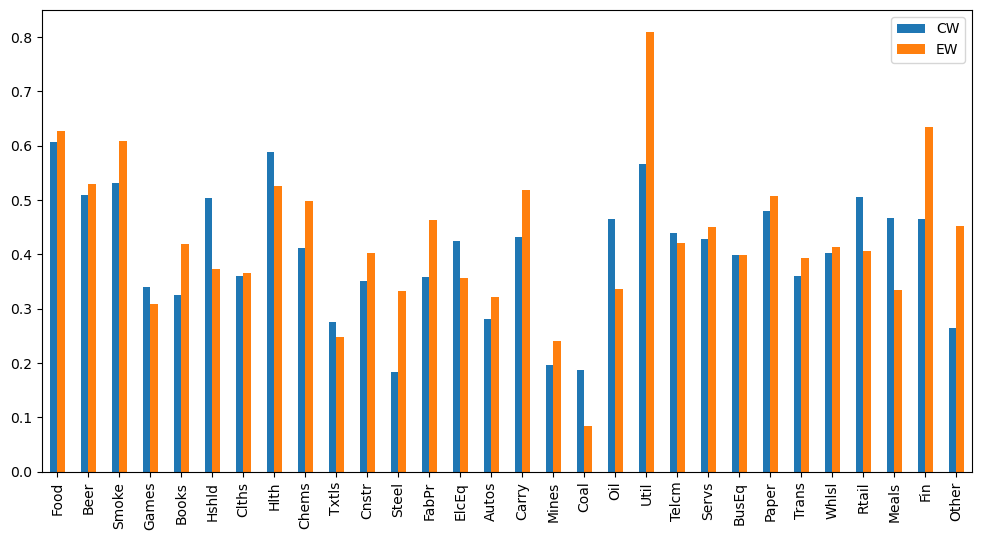

In [10]:
sr.plot.bar(figsize=(12, 6))

In [14]:
(sr['EW'] > sr['CW']).sum() * 100 / sr.shape[0]

np.float64(63.333333333333336)

Text(0.5, 1.0, 'Average Trailing 5 year Sharpe Ratio across 30 Industry Portfolios 1945-2018')

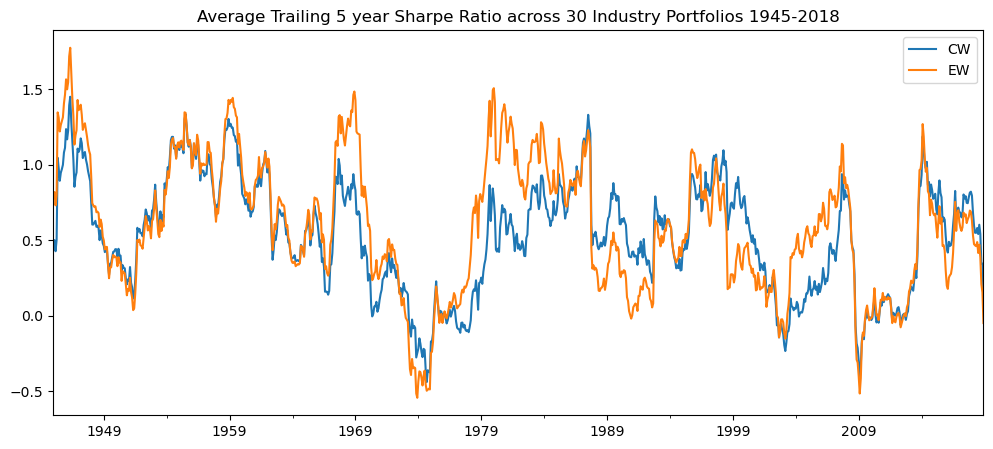

In [22]:
ax = ind_cw.rolling(60).apply(rk.sharpe_ratio, raw=True, kwargs={"riskfree_rate":0.03, "periods_per_year":12}).mean(axis=1)["1945":].plot(figsize=(12,5), label="CW", legend=True)
ind_ew.rolling(60).apply(rk.sharpe_ratio, raw=True, kwargs={"riskfree_rate":0.03, "periods_per_year":12}).mean(axis=1)["1945":].plot(ax=ax, label="EW", legend=True)
ax.set_title("Average Trailing 5 year Sharpe Ratio across 30 Industry Portfolios 1945-2018")